<a href="https://colab.research.google.com/github/Polqer/diplommel1/blob/main/Hyperspectral_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Что вообще нужно сделать?

1. Научиться создавать датасет и даталоадер с .mat файлом:
  * создать кастомный resize - сделано
2. Подобрать модель для этих файлов:
  * можно попробовать resnet
3. Обучить

In [2]:
import torch
import torchvision
from torch import nn
import scipy
import os
import random
import matplotlib.pyplot as plt
from typing import Dict, Tuple, List, Union
from torchvision import models

try:
  import torchinfo
except ModuleNotFoundError:
  !pip install torchinfo
  import torchinfo

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cpu


### Загрузим данные с гугл диска

Ссылка: https://drive.google.com/drive/folders/13ZXXxtUMjEzLAjoAqC19IJEc5RgpFf2f


In [ ]:
# import scipy

# image1 = scipy.io.loadmat('/content/1.mat')['DataCubeC']
# image1.shape

In [4]:
from PIL import Image
from matplotlib import pyplot as plt


# Для отображения numpy изображений до обработки
def plot_mat(image):
  # Создание фигуры и осей
  fig, axes = plt.subplots(
    ncols=4,
    nrows=4,
    sharex=True,
    sharey=True,
    figsize=(16, 16)
  )

  for i in range(4):
      for j in range(4):
          ax = axes[i, j]  # Получаем текущую ось
          ax.imshow(image[:, :, i*4+j], cmap='gray')  # Отображаем изображение
          ax.axis(False)  # Отключаем оси

  plt.tight_layout()
  fig.suptitle('Mat изображение по слоям')
  plt.show()

# Для отображения tensor изображений после преобразований
def plot_mat_tensor(image):
  # Создание фигуры и осей
  fig, axes = plt.subplots(
    ncols=4,
    nrows=4,
    sharex=True,
    sharey=True,
    figsize=(16, 16)
  )

  for i in range(4):
      for j in range(4):
          ax = axes[i, j]  # Получаем текущую ось
          ax.imshow(image[i*4+j, :, :], cmap='gray')  # Отображаем изображение
          ax.axis(False)  # Отключаем оси

  plt.tight_layout()
  fig.suptitle('Mat изображение по слоям')
  plt.show()

### Подгрузим данные

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
from pathlib import Path
import os

data_path = Path('/content/drive/MyDrive/hyperspectral')

dn_data = data_path / 'DNCube'
mm_data = data_path / 'MMCube'

len(os.listdir(dn_data)), len(os.listdir(mm_data)) # Распределение классов неравномерное!!!

(185, 85)

Выведем рандомное изображение /content/drive/MyDrive/hyperspectral/DNCube/1.mat


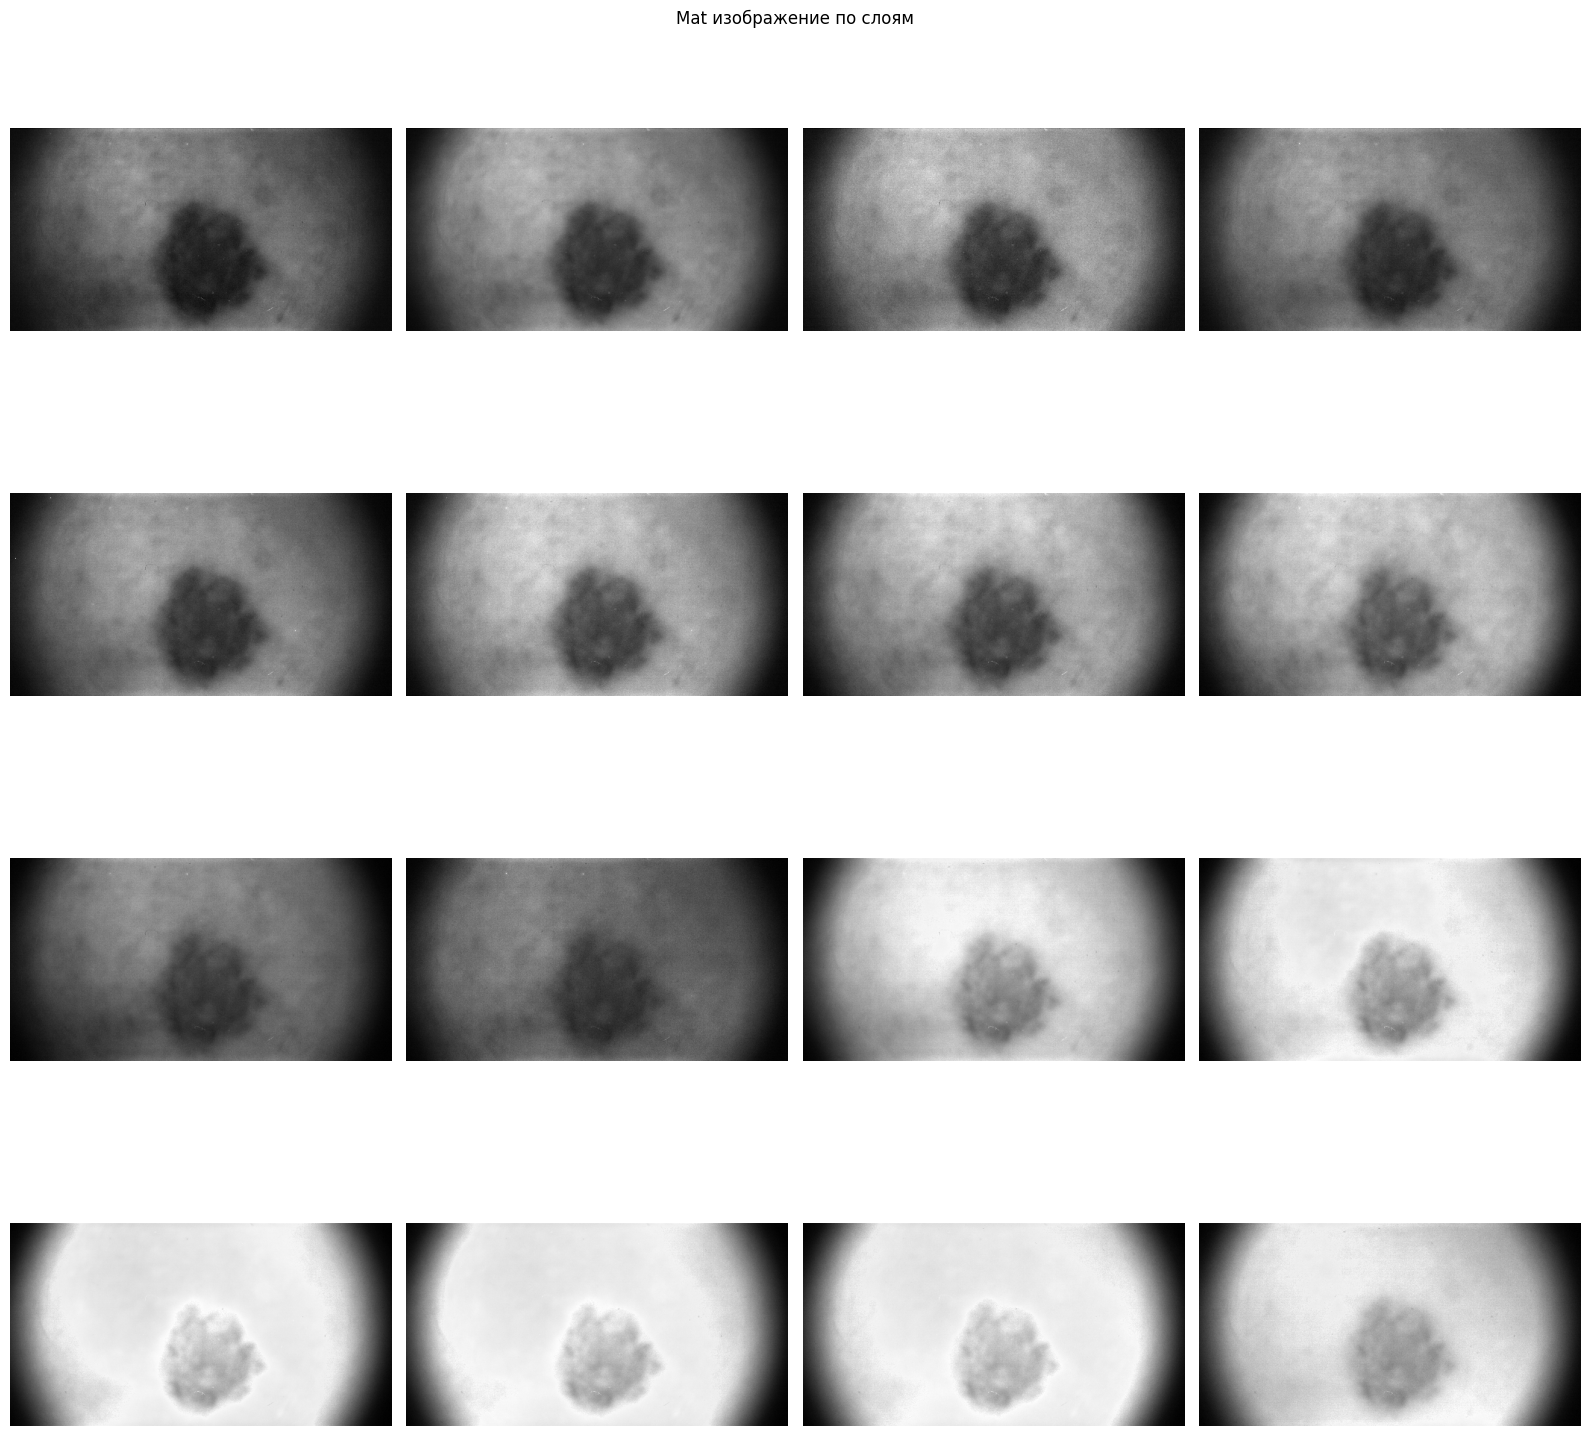

In [ ]:
random_num = random.randint(0, 189)
print('Выведем рандомное изображение', dn_data / next(iter(os.walk(dn_data)))[2][random_num])
random_image = scipy.io.loadmat(dn_data / next(iter(os.walk(dn_data)))[2][random_num])['DataCubeC']
plot_mat(random_image)

In [ ]:
random_image[0, 0].dtype

dtype('<f8')

#### Создадим правильную файловую структуру

/dataset
</br>├── train
</br>│   ├── MMCube
</br>│   ├── DNCube
</br>├── val
</br>│   ├── MMCube
</br>│   ├── DNCube
</br>├── test
</br>│   ├── MMCube
</br>│   ├── DNCube




In [6]:
import shutil
from pathlib import Path

try:
  os.mkdir('./dataset')
except FileExistsError:
  !rm -r ./dataset
  os.mkdir('./dataset')

dataset_dir = Path('/content/dataset')

categories = ["MMCube", "DNCube"]
splits = {"train": 0.8, "val": 0.15, "test": 0.05}

for dir in splits.keys():
  for category in categories:
    os.makedirs(dataset_dir / dir / category)


def split_and_move(category):
    src_dir = os.path.join(data_path, category)
    files = os.listdir(src_dir)
    random.shuffle(files)  # Перемешиваем файлы

    # Вычисляем размеры наборов
    train_size = int(len(files) * splits["train"])
    val_size = int(len(files) * splits["val"])

    split_files = {
        "train": files[:train_size],
        "val": files[train_size:train_size + val_size],
        "test": files[train_size + val_size:]
    }

    # Копируем файлы
    for split, file_list in split_files.items():
        for file in file_list:
            src_path = os.path.join(src_dir, file)
            dst_path = os.path.join(dataset_dir, split, category, file)
            shutil.copy2(src_path, dst_path)  # Копируем файл

# Разделяем файлы для каждой категории
for category in categories:
    split_and_move(category)

KeyboardInterrupt: 

In [ ]:
# Раскомментить и запустить в случае ошибки в предыдущей ячейке (уже не нужно, просто перезапустить предыдущую ячейку)
# !rm -r dataset/

In [6]:
import shutil
from pathlib import Path
dataset_dir = Path('/content/drive/MyDrive/hypers')
train_dir = dataset_dir / 'train'
test_dir = dataset_dir / 'test'
val_dir = dataset_dir / 'val'

train_dir, val_dir, test_dir

(PosixPath('/content/drive/MyDrive/hypers/train'),
 PosixPath('/content/drive/MyDrive/hypers/val'),
 PosixPath('/content/drive/MyDrive/hypers/test'))

### Создадим датасет и даталоадеры

Оф документация: https://pytorch.org/tutorials/beginner/basics/data_tutorial.html

In [7]:
import os
classes = sorted(os.listdir(test_dir))

In [8]:
from torch.utils.data import Dataset, DataLoader
from typing import Union, Tuple


class HyperSpectralDataset(Dataset):
    def __init__(self, root: Union[str, Path], transforms = None, dtype = torch.float) -> None:
        self.folder_path = root
        self.paths = list(Path(root).glob('*/*.mat'))
        self.transforms = transforms
        self.dtype = dtype
        self.classes = sorted(os.listdir(root))

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.float]:
        file_path = self.paths[idx]
        class_name = file_path.parent.name
        class_idx = torch.tensor(self.classes.index(class_name), dtype=torch.float)

        # Загрузка .mat файла
        mat_data = scipy.io.loadmat(file_path).get('DataCubeC')

        # Перестановка осей
        # Из (height, width, channels) в (channels, height, width)
        hyperspectral_image = torch.tensor(mat_data, dtype=self.dtype)
        hyperspectral_image = hyperspectral_image.permute(2, 0, 1)

        # Преобразуем значения к [0, 1]
        min_val = hyperspectral_image.min()
        max_val = hyperspectral_image.max()
        hyperspectral_image = (hyperspectral_image - min_val) / (max_val - min_val)

        if self.transforms:
          hyperspectral_image = self.transforms(hyperspectral_image)

        return (hyperspectral_image, class_idx)

In [9]:
from typing import Optional, List, Tuple, Sequence, Union
from torchvision.transforms.v2.functional import resize
import torch
import torch.nn as nn
import torchvision.transforms.functional as F


class MatResize(nn.Module):
  def __init__(self, size: Union[List, Tuple], interpolation='bilinear') -> None:
    super().__init__()
    self.size = size
    self.interpolation = interpolation

  def forward(self, img: torch.Tensor) -> torch.Tensor:
    return resize(img, self.size)



class MatCenterCrop(nn.Module):
    def __init__(self, size: Union[int, Tuple[int, int]]) -> None:
        super().__init__()
        self.size = size

    def forward(self, img: torch.Tensor) -> torch.Tensor:
        # If size is an integer, make it a square crop
        if isinstance(self.size, int):
            return F.center_crop(img, self.size)
        else:
            return F.center_crop(img, self.size)

class MatNormalize(nn.Module):
  def __init__(self, mean: Sequence[float], std: Sequence[float], inplace: bool=False) -> None:
    super().__init__()
    self.mean = mean
    self.std = std
    self.inplace = inplace

  def forward(self, tensor: torch.Tensor) -> torch.Tensor:
    if not self.inplace:
        tensor = tensor.clone()

    dtype = tensor.dtype
    mean = torch.as_tensor(self.mean, dtype=dtype, device=tensor.device)
    std = torch.as_tensor(self.std, dtype=dtype, device=tensor.device)

    if (std == 0).any():
        raise ValueError(f"std evaluated to zero after conversion to {dtype}, leading to division by zero.")

    if mean.ndim == 1:
        mean = mean.view(-1, 1, 1)
    if std.ndim == 1:
        std = std.view(-1, 1, 1)

    return tensor.sub_(mean).div_(std)

In [10]:
from torchvision.transforms import v2 as transforms
from torchvision import datasets


batch_size = 32

img_transforms = transforms.Compose([
    MatCenterCrop((200, 500)),
    MatResize(size=(255, 255)),
    MatNormalize(mean=0.456, std=0.224)
])


train_dataset = HyperSpectralDataset(
    root=train_dir,
    transforms=img_transforms
)

# val_dataset = HyperSpectralDataset(
#     root=val_dir,
#     transforms=img_transforms
# )

test_dataset = HyperSpectralDataset(
    root=test_dir,
    transforms=img_transforms
)


train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=os.cpu_count()
  )

# val_dataloader = DataLoader(
#     val_dataset,
#     batch_size=batch_size,
#     shuffle=False,
#     num_workers=os.cpu_count()
#   )

test_dataloader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    num_workers=os.cpu_count()
  )

In [12]:
imgs = next(iter(train_dataset))
imgs[0].shape

torch.Size([16, 255, 255])

In [1]:
imgs = next(iter(train_dataloader))
img = imgs[0]
print(f'Shape: {img[0].shape}')

plot_mat_tensor(imgs[0][6])

NameError: name 'train_dataloader' is not defined

### Model 1 - ResNet

Тут берем дефолтный предобученный resnet и адаптируем под задачу


In [ ]:
from torchvision import models


resnet152_weights = models.ResNet152_Weights.DEFAULT
model1 = models.resnet152(weights=resnet152_weights)

for param in model1.parameters():
  param.requires_grad = False

model1.conv1 = nn.Conv2d(
    in_channels=16,
    out_channels=64,
    kernel_size=(7, 7),
    stride=(2, 2),
    padding=(3, 3),
    bias=False,
)

model1.fc = nn.Linear(
    in_features=model1.fc.in_features,
    out_features=1, # len(classes), раскомментить в случае добавления еще классов
    bias=True,
)

torchinfo.summary(
    model=model1,
    input_size=(16, 16, 256, 256),
    col_names=['input_size', 'output_size', 'num_params', 'trainable'],
    col_width=20,
    row_settings=['var_names'],
)

Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth
100%|██████████| 230M/230M [00:01<00:00, 161MB/s]


Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
ResNet (ResNet)                          [16, 16, 256, 256]   [16, 1]              --                   Partial
├─Conv2d (conv1)                         [16, 16, 256, 256]   [16, 64, 128, 128]   50,176               True
├─BatchNorm2d (bn1)                      [16, 64, 128, 128]   [16, 64, 128, 128]   (128)                False
├─ReLU (relu)                            [16, 64, 128, 128]   [16, 64, 128, 128]   --                   --
├─MaxPool2d (maxpool)                    [16, 64, 128, 128]   [16, 64, 64, 64]     --                   --
├─Sequential (layer1)                    [16, 64, 64, 64]     [16, 256, 64, 64]    --                   False
│    └─Bottleneck (0)                    [16, 64, 64, 64]     [16, 256, 64, 64]    --                   False
│    │    └─Conv2d (conv1)               [16, 64, 64, 64]     [16, 64, 64, 64]     (4,096)              False
│    │    └

.

### Обучение ResNet

In [ ]:
lr = 0.001
epochs = 20

loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(
    params=model1.parameters(),
    lr=lr
)

NameError: name 'model1' is not defined

  0%|          | 0/20 [00:00<?, ?it/s]


        Epoch: 1 | Train loss: 0.6374 | Train accuracy: 64.81% | Test loss: 0.6165 | Test accuracy: 70.00%
        

        Epoch: 2 | Train loss: 0.6085 | Train accuracy: 68.52% | Test loss: 0.6079 | Test accuracy: 70.00%
        

        Epoch: 3 | Train loss: 0.5943 | Train accuracy: 68.52% | Test loss: 0.5881 | Test accuracy: 72.50%
        

        Epoch: 4 | Train loss: 0.5857 | Train accuracy: 70.83% | Test loss: 0.6207 | Test accuracy: 70.00%
        

        Epoch: 5 | Train loss: 0.6023 | Train accuracy: 70.37% | Test loss: 0.5581 | Test accuracy: 70.00%
        

        Epoch: 6 | Train loss: 0.5960 | Train accuracy: 69.44% | Test loss: 0.5925 | Test accuracy: 70.00%
        

        Epoch: 7 | Train loss: 0.5914 | Train accuracy: 70.83% | Test loss: 0.6184 | Test accuracy: 70.00%
        

        Epoch: 8 | Train loss: 0.5949 | Train accuracy: 68.98% | Test loss: 0.5811 | Test accuracy: 70.00%
        

        Epoch: 9 | Train loss: 0.5914 | Train accuracy: 68.06% 

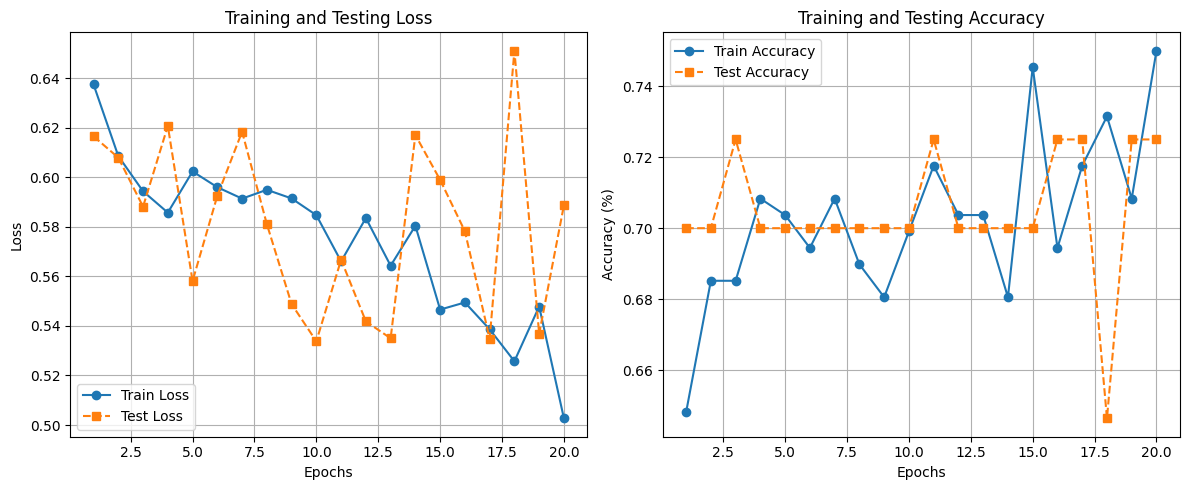

In [ ]:
result = train(
    model=model1,
    train_dataloader=train_dataloader,
    test_dataloader=val_dataloader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    epochs=epochs,
    device=device,
)

plot_metrics(result)

 .

### Model2 - Модели обученные на ISIC-датасете

Попробуем модели, предобученные на ISIC-датасете

In [ ]:
from tqdm.auto import tqdm
import torch
import wandb
from typing import Dict, Tuple, List
from sklearn.metrics import precision_score, recall_score, f1_score

def train_step(
    model: torch.nn.Module,
    dataloader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device
  ) -> Tuple[float, float]:
  """
  Одноэпохальное обучение модели
  """
  model.train()
  train_loss, train_acc = 0, 0
  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)
    preds = model(X).squeeze(dim=1).sigmoid()
    loss = loss_fn(preds, y)
    train_loss += loss.item()
    pred_labels = preds.round()
    train_acc += (pred_labels == y).sum().item() / len(y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  return train_loss / len(dataloader), train_acc / len(dataloader)


wandb.init(project="skin-lesion-classification", name="ef")


def test_step(
    model: torch.nn.Module,
    dataloader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    device: torch.device
  ) -> Tuple[float, float, float, float, float]:
  """
  Одноэпохальное тестирование модели с вычислением метрик
  """
  test_loss, test_acc = 0, 0
  all_preds, all_labels = [], []
  model.eval()
  with torch.inference_mode():
    for X_test, y_test in dataloader:
      X_test, y_test = X_test.to(device), y_test.to(device)
      test_preds = model(X_test).squeeze(dim=1).sigmoid()
      test_loss += loss_fn(test_preds, y_test).item()
      threshold = 0.47
#      test_labels = test_preds.round()
      test_labels = (test_preds >= threshold).float()

      test_acc += (test_labels == y_test).sum().item() / len(y_test)
      all_preds.extend(test_labels.cpu().numpy())
      all_labels.extend(y_test.cpu().numpy())
  precision = precision_score(all_labels, all_preds, zero_division=0)
  recall = recall_score(all_labels, all_preds, zero_division=0)
  f1 = f1_score(all_labels, all_preds, zero_division=0)
  return test_loss / len(dataloader), test_acc / len(dataloader), precision, recall, f1

def train(
    model: torch.nn.Module,
    train_dataloader: torch.utils.data.DataLoader,
    test_dataloader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    epochs: int,
    device: torch.device
  ) -> Dict[str, List[float]]:
  """
  Полный цикл обучения и тестирования модели с логированием в wandb
  """





  results = { 'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': [], 'precision': [], 'recall': [], 'f1_score': [] }
  for epoch in tqdm(range(epochs)):
    train_loss, train_acc = train_step(model, train_dataloader, loss_fn, optimizer, device)
    test_loss, test_acc, precision, recall, f1_score = test_step(model, test_dataloader, loss_fn, device)
    print(f"Epoch: {epoch+1} | Train loss: {train_loss:.4f} | Train acc: {train_acc*100:.2f}% | Test loss: {test_loss:.4f} | Test acc: {test_acc*100:.2f}% | Precision: {precision:.4f} | Recall: {recall:.4f} | F1-score: {f1_score:.4f}")
    wandb.log({"epoch": epoch+1, "train_loss": train_loss, "train_acc": train_acc, "test_loss": test_loss, "test_acc": test_acc, "precision": precision, "recall": recall, "f1_score": f1_score})
    results['train_loss'].append(train_loss)
    results['train_acc'].append(train_acc)
    results['test_loss'].append(test_loss)
    results['test_acc'].append(test_acc)
    results['precision'].append(precision)
    results['recall'].append(recall)
    results['f1_score'].append(f1_score)
  wandb.finish()
  return results

def plot_metrics(result: Dict[str, List[float]]) -> None:
  """
  Функция для построения графиков потерь и точности.

  :param result: Словарь, содержащий ключи 'train_loss', 'test_loss', 'train_acc', 'test_acc'
  """
  train_loss = result['train_loss']
  test_loss = result['test_loss']
  train_acc = result['train_acc']
  test_acc = result['test_acc']

  epochs = range(1, len(result['train_loss']) + 1)

  fig, axes = plt.subplots(1, 2, figsize=(12, 5))

  # График потерь
  axes[0].plot(epochs, train_loss, label='Train Loss', linestyle='-')
  axes[0].plot(epochs, test_loss, label='Test Loss')
  axes[0].set_title('Training and Testing Loss')
  axes[0].set_xlabel('Epochs')
  axes[0].set_ylabel('Loss')
  axes[0].legend()
  axes[0].grid()

  # График точности
  axes[1].plot(epochs, train_acc, label='Train Accuracy', linestyle='-')
  axes[1].plot(epochs, test_acc, label='Test Accuracy')
  axes[1].set_title('Training and Testing Accuracy')
  axes[1].set_xlabel('Epochs')
  axes[1].set_ylabel('Accuracy (%)')
  axes[1].legend()
  axes[1].grid()

  # Показ графиков
  plt.tight_layout()
  plt.show()

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

KeyboardInterrupt: 

In [11]:
from torchvision import models
import io

# Загрузим веса
weights2 = torch.load('/content/drive/MyDrive/efficientnet_b1_best.pt', weights_only=True)

# Изменим модель, чтобы веса "встали"
model2 = models.efficientnet_b1()
model2.classifier[1] = nn.Linear(in_features=1280, out_features=9, bias=True)
model2.load_state_dict(weights2)

# Заморозим параметры
for param in model2.parameters():
  param.requires_grad = False

# Адаптируем под нашу задачу
model2.features[0][0] = nn.Conv2d(
    in_channels=16,
    out_channels=32,
    kernel_size=(3, 3),
    stride=(2, 2),
    padding=(1, 1),
    bias=False,
)
model2.classifier[1] = nn.Linear(in_features=1280, out_features=1, bias=True)

torchinfo.summary(
    model=model2,
    input_size=(8, 16, 255, 255),
    col_names=['input_size', 'output_size', 'num_params', 'trainable'],
    col_width=20,
    row_settings=['var_names'],
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [8, 16, 255, 255]    [8, 1]               --                   Partial
├─Sequential (features)                                      [8, 16, 255, 255]    [8, 1280, 8, 8]      --                   Partial
│    └─Conv2dNormActivation (0)                              [8, 16, 255, 255]    [8, 32, 128, 128]    --                   Partial
│    │    └─Conv2d (0)                                       [8, 16, 255, 255]    [8, 32, 128, 128]    4,608                True
│    │    └─BatchNorm2d (1)                                  [8, 32, 128, 128]    [8, 32, 128, 128]    (64)                 False
│    │    └─SiLU (2)                                         [8, 32, 128, 128]    [8, 32, 128, 128]    --                   --
│    └─Sequential (1)                                        [8, 32, 128, 128]    [8

In [ ]:
lr = 0.0001
epochs = 30
loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(
    params=model2.parameters(),
    lr=lr
)

result = train(
    model=model2,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    epochs=epochs,
    device=device,
)

plot_metrics(result)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (<ipython-input-33-f227f6bc2db9>, line 10)

### Model3 - Модели обученные на ISIC-датасете VIT

Попробуем модели, предобученные на ISIC-датасете

In [ ]:
from torchvision import models
import io
from torch import nn
import torch
import io
!pip install torchinfo
from torchinfo import summary
from torchvision import models
try:
  import torchinfo
except ModuleNotFoundError:
  !pip install torchinfo
  import torchinfo
from google.colab import drive
drive.mount('/content/drive')
# Загрузим веса
weights2 = torch.load("/content/drive/MyDrive/vit_b_16_best.pt", map_location=torch.device("cpu"), weights_only=True)
# Изменим модель, чтобы веса "встали"


model2=models.vit_b_16(weights=None)
model2.heads.head = nn.Linear(in_features=768, out_features=9)

model2.load_state_dict(weights2)
# Заморозим параметры
for param in model2.parameters():
    param.requires_grad = False

model2.conv_proj = nn.Conv2d(
    in_channels=16,  # Ваше количество входных каналов
    out_channels=768,  # ViT-b/16 использует 768 каналов для проекций
    kernel_size=16,  # Размер ядра
    stride=16,  # Шаг
    padding=0,  # Отступ
    bias=False
)

model2.heads.head = nn.Linear(in_features=768, out_features=1, bias=True)

torchinfo.summary(
model=model2,
input_size=(8, 16, 224, 224),
col_names=['input_size', 'output_size', 'num_params', 'trainable'],
col_width=20,
row_settings=['var_names'],
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
VisionTransformer (VisionTransformer)                        [8, 16, 224, 224]    [8, 1]               768                  Partial
├─Conv2d (conv_proj)                                         [8, 16, 224, 224]    [8, 768, 14, 14]     3,145,728            True
├─Encoder (encoder)                                          [8, 197, 768]        [8, 197, 768]        151,296              False
│    └─Dropout (dropout)                                     [8, 197, 768]        [8, 197, 768]        --                   --
│    └─Sequential (layers)                                   [8, 197, 768]        [8, 197, 768]        --                   False
│    │    └─EncoderBlock (encoder_layer_0)                   [8, 197, 768]        [8, 197, 768]        (7,087,872)          False
│    │    └─EncoderBlock (encoder_layer_1)                   [8, 197, 768]        [8, 19

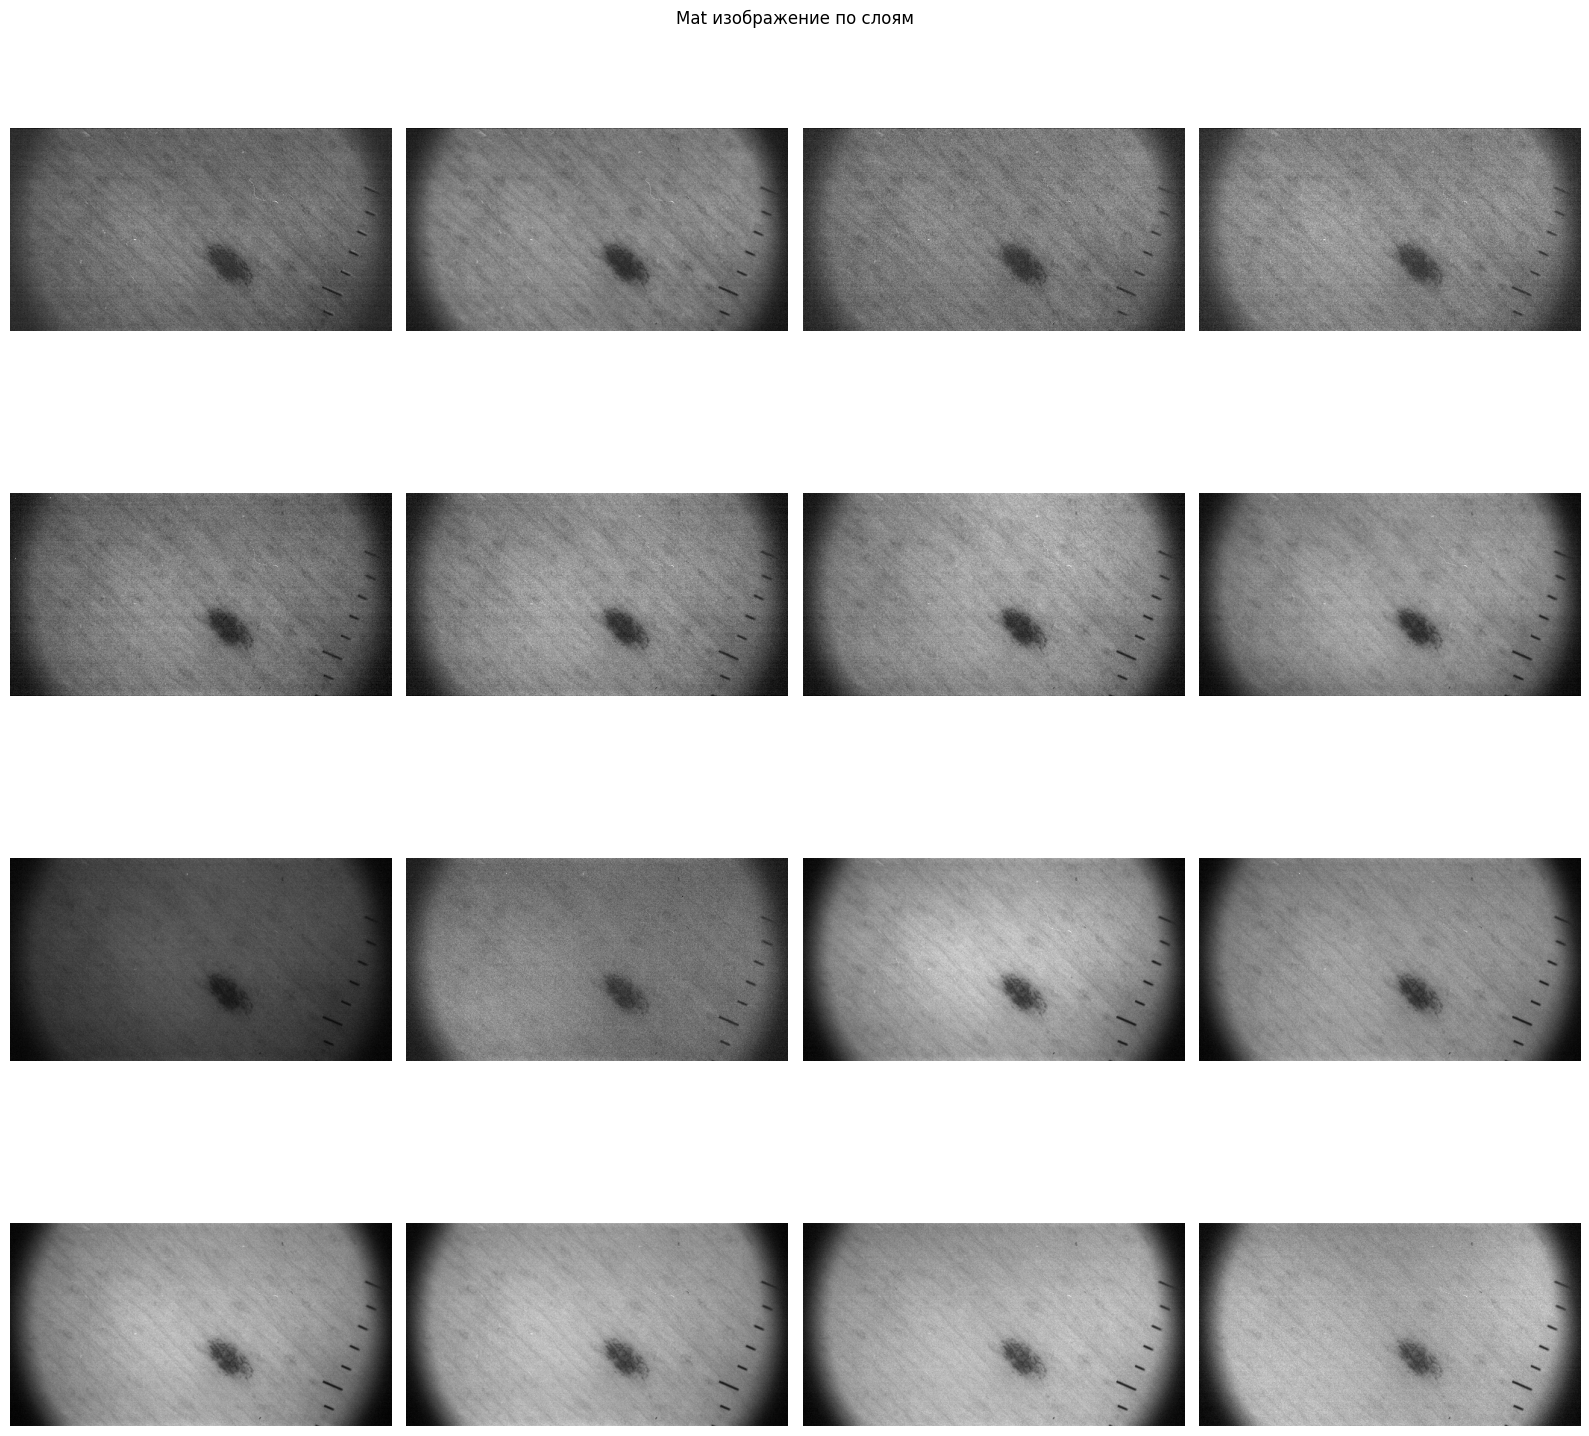

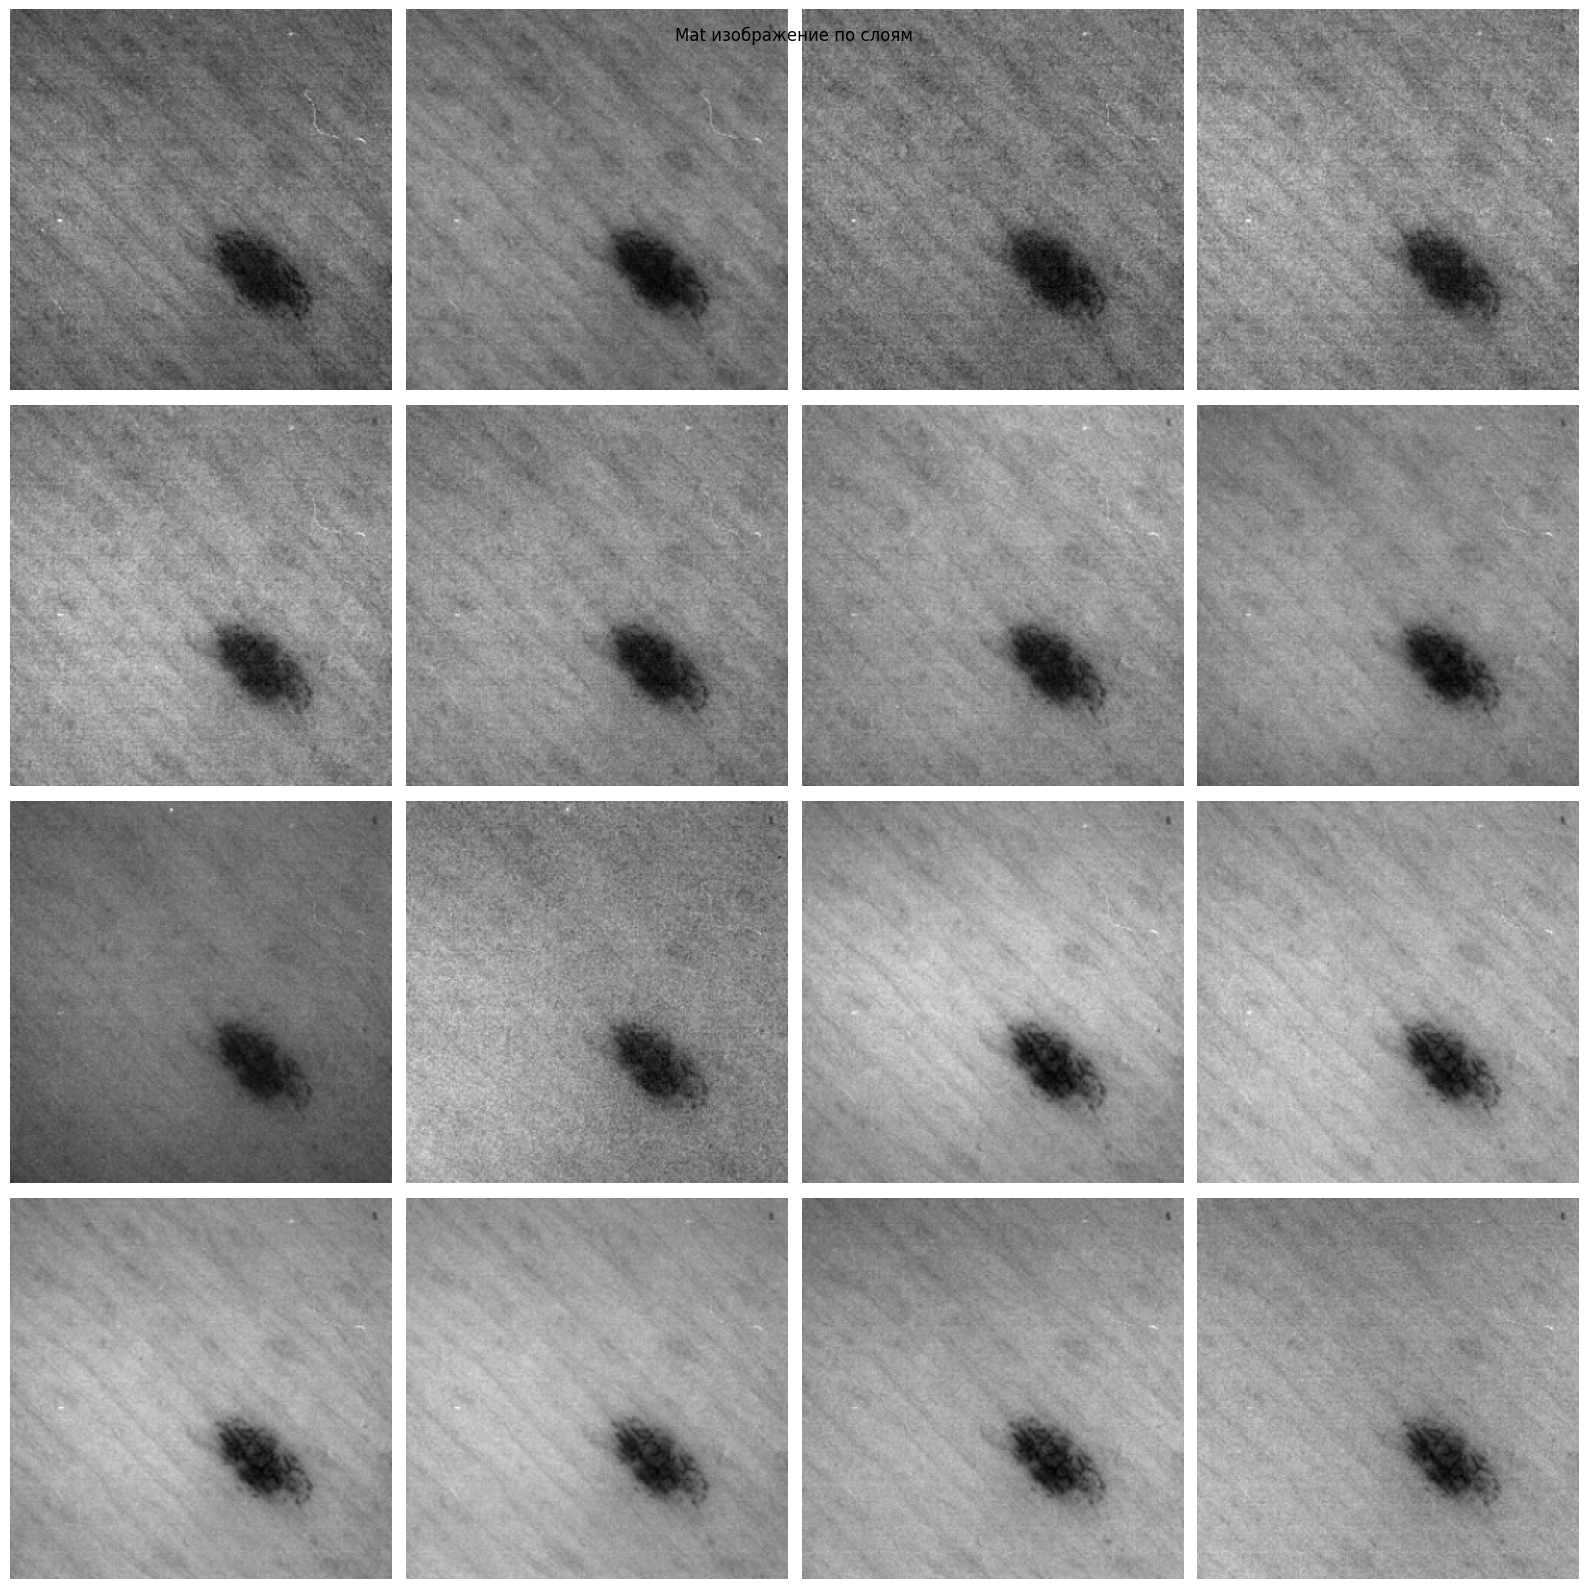

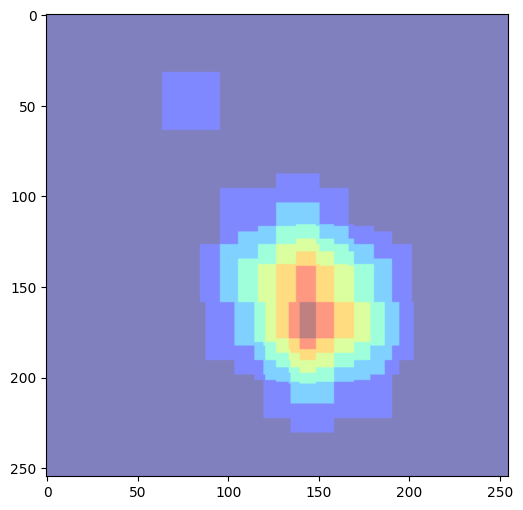

In [17]:
import os
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image
import torch
from torch import nn
from torchvision import models, transforms
from torch.autograd import Variable
import scipy.io
import torchinfo
from scipy.ndimage import zoom
import numpy as np

class Flatten(nn.Module):
    def __init__(self):
        super(Flatten, self).__init__()

    def forward(self, x):
        return x.view(x.size(0), -1)


# Загружаем изображение
random_image = scipy.io.loadmat("/content/drive/MyDrive/hyperspectral/DNCube/178.mat")['DataCubeC']
plot_mat(random_image)

# Трансформации
img_transforms = transforms.Compose([
    transforms.CenterCrop((240)),
    transforms.Resize((255, 255)),
    transforms.Normalize(mean=[0.456], std=[0.224])
])

# Преобразуем в тензор
random_image = torch.tensor(random_image, dtype=torch.float)

# Перестановка осей: (H, W, C) → (C, H, W)
random_image = random_image.permute(2, 0, 1)

# Нормализация
min_val = random_image.min()
max_val = random_image.max()
random_image = (random_image - min_val) / (max_val - min_val)

# Применение трансформаций

random_image = img_transforms(random_image)
plot_mat_tensor(random_image)

# Подготовка данных
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pred = random_image.unsqueeze(0).to(device)

# Загружаем веса
weights2 = torch.load('/content/drive/MyDrive/efficientnet_b1_best.pt', weights_only=True)

# Изменяем модель
model2 = models.efficientnet_b1()
model2.classifier[1] = nn.Linear(in_features=1280, out_features=9, bias=True)
model2.load_state_dict(weights2)

# Заморозка параметров модели
for param in model2.parameters():
    param.requires_grad = False

# Адаптация модели
model2.features[0][0] = nn.Conv2d(
    in_channels=16,
    out_channels=32,
    kernel_size=(3, 3),
    stride=(2, 2),
    padding=(1, 1),
    bias=False,
)
model2.classifier[1] = nn.Linear(in_features=1280, out_features=1, bias=True)

# Используем модель в режиме оценки
model2 = model2.eval().to(device)

# Разделяем модель на части
f_ex = nn.Sequential(*list(model2.children())[:-2])
classification = nn.Sequential(*(list(model2.children())[-2:-1] + [Flatten()] + list(model2.children())[-1:]))

# Проверяем структуру модели
torchinfo.summary(
    model=model2,
    input_size=(1, 16, 255, 255),
    col_names=['input_size', 'output_size', 'num_params', 'trainable'],
    col_width=20,
    row_settings=['var_names'],
)


# Функция GradCAM с сайта
def GradCAM(img, cl_sc, f_ex, classification):
    f_map = f_ex(img)
    _, C, H, W = f_map.size()
    c_score = classification(f_map)[0]
    grads = torch.autograd.grad(c_score, f_map)[0]
    w = grads.mean(dim=[2, 3])
    gradcam = torch.einsum('c,chw->hw', w[0], f_map[0])
    gradcam = np.maximum(gradcam.cpu().detach().numpy(), 0)
    return gradcam


# Прогонка изображения через модель
prob, class_cl = torch.topk(nn.Softmax(dim=1)(model2(pred)), 1)
class_idx = class_cl[0][0].item()

gradcam = GradCAM(pred, class_idx, f_ex, classification)
# Преобразуем в изображение
gradcam = Image.fromarray((gradcam * 255).astype(np.uint8))
gradcam = gradcam.resize((random_image.shape[2], random_image.shape[1]), resample=Image.BILINEAR)
# Визуализация
plt.figure(figsize=(6, 6))
plt.imshow(np.array(gradcam), alpha=0.5, cmap='jet')
plt.show()


epoch,▁█
f1_score,▁▁
precision,▁▁
recall,▁▁
test_acc,▁▁
test_loss,█▁
train_acc,█▁
train_loss,█▁
epoch,2
f1_score,0
precision,0


Create sweep with ID: ruqfsihe
Sweep URL: https://wandb.ai/polina-delitzsch-etu/skin-lesion-classification_efficientnet/sweeps/ruqfsihe


wandb: Agent Starting Run: dum0j2xb with config:
wandb: 	batch_size: 64
wandb: 	epochs: 20
wandb: 	lr: 1e-05
wandb: 	opt: adam
wandb: 	threshold: 0.6


  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1 | Train loss: 0.7322 | Train acc: 44.79% | Test loss: 0.6864 | Test acc: 63.54% | Precision: 0.0000 | Recall: 0.0000 | F1-score: 0.0000
Epoch: 2 | Train loss: 0.7235 | Train acc: 36.98% | Test loss: 0.6820 | Test acc: 62.50% | Precision: 0.0000 | Recall: 0.0000 | F1-score: 0.0000
Epoch: 3 | Train loss: 0.7228 | Train acc: 38.02% | Test loss: 0.6882 | Test acc: 63.73% | Precision: 0.5000 | Recall: 0.0333 | F1-score: 0.0625
Модель сохранена в /content/drive/MyDrive/best_model.pth
Epoch: 4 | Train loss: 0.7038 | Train acc: 48.44% | Test loss: 0.6960 | Test acc: 61.65% | Precision: 0.2500 | Recall: 0.0333 | F1-score: 0.0588
Epoch: 5 | Train loss: 0.6897 | Train acc: 51.56% | Test loss: 0.7078 | Test acc: 60.80% | Precision: 0.2857 | Recall: 0.0667 | F1-score: 0.1081
Модель сохранена в /content/drive/MyDrive/best_model.pth
Epoch: 6 | Train loss: 0.7231 | Train acc: 39.58% | Test loss: 0.7184 | Test acc: 59.76% | Precision: 0.2500 | Recall: 0.0667 | F1-score: 0.1053
Epoch: 7 | Train

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
f1_score,▁▁▅▅▇▇▇█▅▅▅▅▅▅▅▅▅▅▅▅
precision,▁▁█▅▅▅▅█▆▅▅▆▆███▆█▆█
recall,▁▁▅▅████▅▅▅▅▅▅▅▅▅▅▅▅
test_acc,▇▆█▄▃▁▃█▆▄▄▆▆███▆█▆█
test_loss,▂▁▂▃▅▇█▇▇▆▅▄▄▄▄▃▄▃▃▃
train_acc,▃▁▁▄▅▂▄▃▄▄▆▇█▅▇▆▄▇▅█
train_loss,█▇▇▅▃▇▄▆▅▅▄▃▃▄▂▃▄▂▃▁
epoch,20
f1_score,0.0625
precision,0.5


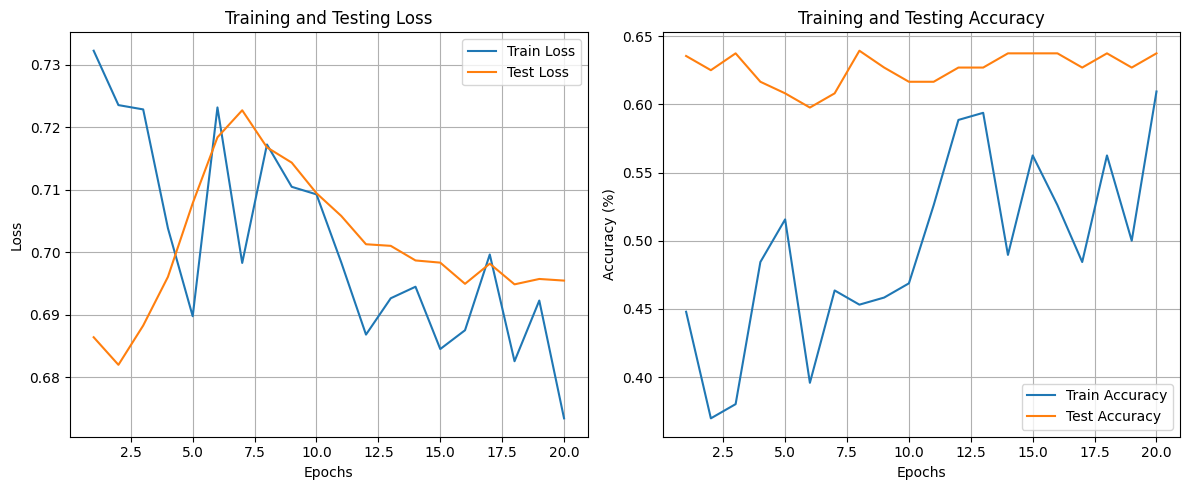

wandb: Agent Starting Run: iulwlqz2 with config:
wandb: 	batch_size: 32
wandb: 	epochs: 15
wandb: 	lr: 1e-05
wandb: 	opt: sgd
wandb: 	threshold: 0.7


  0%|          | 0/15 [00:00<?, ?it/s]

Epoch: 1 | Train loss: 0.6901 | Train acc: 53.12% | Test loss: 0.6923 | Test acc: 63.54% | Precision: 0.0000 | Recall: 0.0000 | F1-score: 0.0000
Epoch: 2 | Train loss: 0.6591 | Train acc: 68.75% | Test loss: 0.6959 | Test acc: 63.54% | Precision: 0.0000 | Recall: 0.0000 | F1-score: 0.0000
Epoch: 3 | Train loss: 0.6789 | Train acc: 55.73% | Test loss: 0.6962 | Test acc: 63.54% | Precision: 0.0000 | Recall: 0.0000 | F1-score: 0.0000
Epoch: 4 | Train loss: 0.6828 | Train acc: 57.81% | Test loss: 0.6937 | Test acc: 63.54% | Precision: 0.0000 | Recall: 0.0000 | F1-score: 0.0000
Epoch: 5 | Train loss: 0.6874 | Train acc: 53.65% | Test loss: 0.6909 | Test acc: 63.54% | Precision: 0.0000 | Recall: 0.0000 | F1-score: 0.0000
Epoch: 6 | Train loss: 0.6893 | Train acc: 56.25% | Test loss: 0.6914 | Test acc: 63.54% | Precision: 0.0000 | Recall: 0.0000 | F1-score: 0.0000
Epoch: 7 | Train loss: 0.6737 | Train acc: 58.33% | Test loss: 0.6911 | Test acc: 63.54% | Precision: 0.0000 | Recall: 0.0000 | F1

epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
f1_score,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
precision,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
recall,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test_acc,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test_loss,▆██▆▅▅▅▅▄▄▃▂▂▁▁
train_acc,▃█▄▅▃▄▅▇▆▁▄▅▅▅▅
train_loss,▆▁▄▅▆▆▃▅▂█▃▂▄▂▂
epoch,15
f1_score,0
precision,0


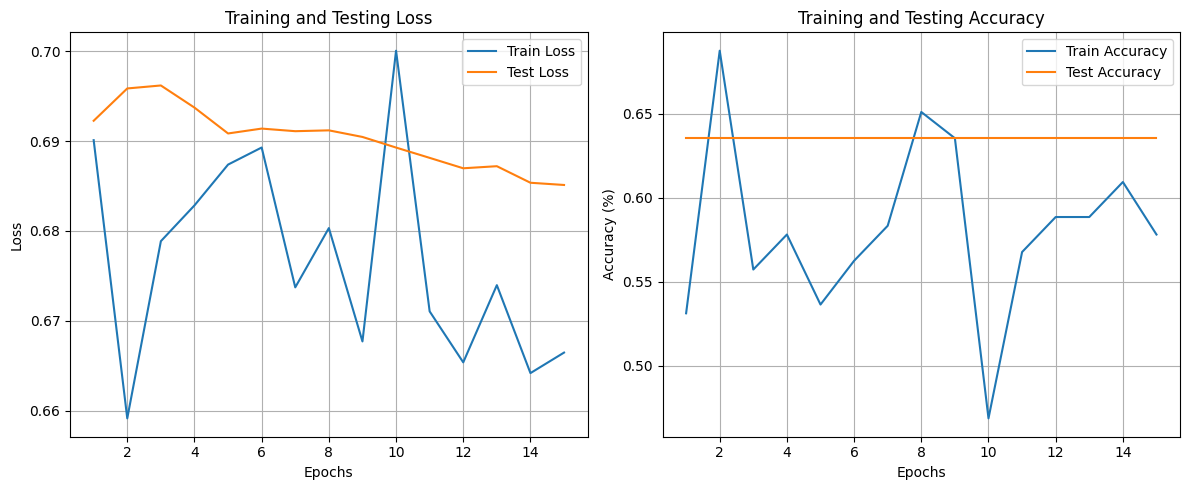

wandb: Agent Starting Run: c83nhtwi with config:
wandb: 	batch_size: 64
wandb: 	epochs: 20
wandb: 	lr: 1e-05
wandb: 	opt: adam
wandb: 	threshold: 0.6


  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1 | Train loss: 0.6649 | Train acc: 57.29% | Test loss: 0.6804 | Test acc: 63.54% | Precision: 0.0000 | Recall: 0.0000 | F1-score: 0.0000
Epoch: 2 | Train loss: 0.6819 | Train acc: 59.38% | Test loss: 0.6825 | Test acc: 64.78% | Precision: 1.0000 | Recall: 0.0333 | F1-score: 0.0645
Модель сохранена в /content/drive/MyDrive/best_model.pth
Epoch: 3 | Train loss: 0.6784 | Train acc: 62.50% | Test loss: 0.6824 | Test acc: 64.78% | Precision: 1.0000 | Recall: 0.0333 | F1-score: 0.0645
Epoch: 4 | Train loss: 0.6628 | Train acc: 67.19% | Test loss: 0.6822 | Test acc: 64.78% | Precision: 1.0000 | Recall: 0.0333 | F1-score: 0.0645
Epoch: 5 | Train loss: 0.6434 | Train acc: 72.40% | Test loss: 0.6794 | Test acc: 64.78% | Precision: 1.0000 | Recall: 0.0333 | F1-score: 0.0645
Epoch: 6 | Train loss: 0.6606 | Train acc: 62.50% | Test loss: 0.6791 | Test acc: 63.54% | Precision: 0.0000 | Recall: 0.0000 | F1-score: 0.0000
Epoch: 7 | Train loss: 0.6536 | Train acc: 72.92% | Test loss: 0.6760 | T

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
f1_score,▁████▁▁▁█▁▁▁▁▁▁▁▁▁▁▁
precision,▁████▁▁▁█▁▁▁▁▁▁▁▁▁▁▁
recall,▁████▁▁▁█▁▁▁▁▁▁▁▁▁▁▁
test_acc,▁████▁▁▁█▁▁▁▁▁▁▁▁▁▁▁
test_loss,▇███▇▇▅▅▆▄▃▃▃▂▃▂▁▁▁▁
train_acc,▂▂▄▆█▄██▁▇█▆▃▄█▅▅▄▄▇
train_loss,▅█▇▅▂▄▃▁▆▃▂▁▆▄▁▆▂▂▅▂
epoch,20
f1_score,0
precision,0


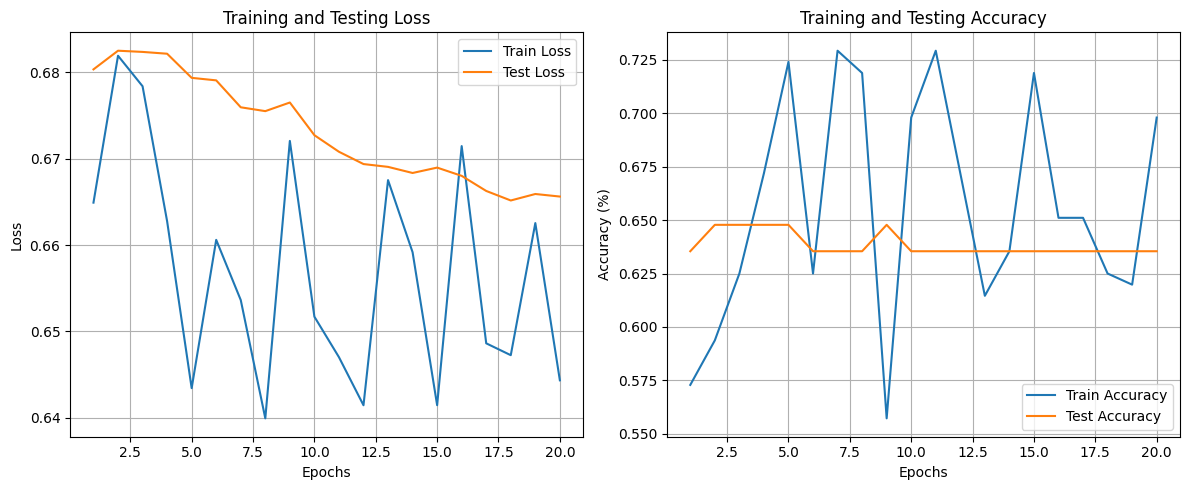

wandb: Agent Starting Run: qyr5zi0g with config:
wandb: 	batch_size: 64
wandb: 	epochs: 15
wandb: 	lr: 1e-05
wandb: 	opt: adam
wandb: 	threshold: 0.7


  0%|          | 0/15 [00:00<?, ?it/s]

Epoch: 1 | Train loss: 0.6369 | Train acc: 69.79% | Test loss: 0.6631 | Test acc: 63.54% | Precision: 0.0000 | Recall: 0.0000 | F1-score: 0.0000


wandb: Ctrl + C detected. Stopping sweep.


In [16]:
from tqdm.auto import tqdm
import torch
import wandb
from typing import Dict, Tuple, List
from sklearn.metrics import precision_score, recall_score, f1_score

def plot_metrics(result: Dict[str, List[float]]) -> None:
  """
  Функция для построения графиков потерь и точности.

  :param result: Словарь, содержащий ключи 'train_loss', 'test_loss', 'train_acc', 'test_acc'
  """
  train_loss = result['train_loss']
  test_loss = result['test_loss']
  train_acc = result['train_acc']
  test_acc = result['test_acc']

  epochs = range(1, len(result['train_loss']) + 1)

  fig, axes = plt.subplots(1, 2, figsize=(12, 5))

  # График потерь
  axes[0].plot(epochs, train_loss, label='Train Loss', linestyle='-')
  axes[0].plot(epochs, test_loss, label='Test Loss')
  axes[0].set_title('Training and Testing Loss')
  axes[0].set_xlabel('Epochs')
  axes[0].set_ylabel('Loss')
  axes[0].legend()
  axes[0].grid()

  # График точности
  axes[1].plot(epochs, train_acc, label='Train Accuracy', linestyle='-')
  axes[1].plot(epochs, test_acc, label='Test Accuracy')
  axes[1].set_title('Training and Testing Accuracy')
  axes[1].set_xlabel('Epochs')
  axes[1].set_ylabel('Accuracy (%)')
  axes[1].legend()
  axes[1].grid()

  # Показ графиков
  plt.tight_layout()
  plt.show()

# Убираем лишний вызов teardown
# wandb.teardown()  # Уберите его отсюда, чтобы не вызывать сбой

def train_step(
    model: torch.nn.Module,
    dataloader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device
) -> Tuple[float, float]:
    model.train()
    train_loss, train_acc = 0, 0
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        preds = model(X).squeeze(dim=1).sigmoid()
        loss = loss_fn(preds, y)
        train_loss += loss.item()
        pred_labels = preds.round()
        train_acc += (pred_labels == y).sum().item() / len(y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    return train_loss / len(dataloader), train_acc / len(dataloader)

def test_step(
    model: torch.nn.Module,
    dataloader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    threshold: float,
    device: torch.device
) -> Tuple[float, float, float, float, float]:
    test_loss, test_acc = 0, 0
    all_preds, all_labels = [], []
    model.eval()
    with torch.inference_mode():
        for X_test, y_test in dataloader:
            X_test, y_test = X_test.to(device), y_test.to(device)
            test_preds = model(X_test).squeeze(dim=1).sigmoid()
            test_loss += loss_fn(test_preds, y_test).item()
            test_labels = (test_preds >= threshold).float()
            test_acc += (test_labels == y_test).sum().item() / len(y_test)
            all_preds.extend(test_labels.cpu().numpy())
            all_labels.extend(y_test.cpu().numpy())

    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    return test_loss / len(dataloader), test_acc / len(dataloader), precision, recall, f1

# Главная функция для тренировки и тестирования модели с логированием в WandB
def train(
    model: torch.nn.Module,
    train_dataloader: torch.utils.data.DataLoader,
    test_dataloader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    epochs: int,
    threshold: float,
    device: torch.device
) -> Dict[str, List[float]]:
    results = {
        'train_loss': [], 'train_acc': [],
        'test_loss': [], 'test_acc': [],
        'precision': [], 'recall': [], 'f1_score': []
    }
    best_f1 = 0.0  # Лучшая F1-мера
    best_model_path = "/content/drive/MyDrive/best_model.pth"  # Путь для сохранения

    for epoch in tqdm(range(epochs)):
        # Training step
        train_loss, train_acc = train_step(model, train_dataloader, loss_fn, optimizer, device)
        # Testing step
        test_loss, test_acc, precision, recall, f1_score = test_step(model, test_dataloader, loss_fn, threshold, device)

        # Log results to WandB
        print(f"Epoch: {epoch+1} | Train loss: {train_loss:.4f} | Train acc: {train_acc*100:.2f}% | "
              f"Test loss: {test_loss:.4f} | Test acc: {test_acc*100:.2f}% | Precision: {precision:.4f} | "
              f"Recall: {recall:.4f} | F1-score: {f1_score:.4f}")

        wandb.log({
            "epoch": epoch + 1, "train_loss": train_loss, "train_acc": train_acc,
            "test_loss": test_loss, "test_acc": test_acc, "precision": precision,
            "recall": recall, "f1_score": f1_score
        })

        # Store metrics
        results['train_loss'].append(train_loss)
        results['train_acc'].append(train_acc)
        results['test_loss'].append(test_loss)
        results['test_acc'].append(test_acc)
        results['precision'].append(precision)
        results['recall'].append(recall)
        results['f1_score'].append(f1_score)

        # Сохранение модели, если F1-score улучшился
        if f1_score > best_f1:
            best_f1 = f1_score
            save_checkpoint(model, epoch + 1, best_f1, best_model_path)

    wandb.finish()  # Ensure finish is called after all runs
    return results

# Sweep-конфигурация
sweep_configuration = {
    "method": "random",
    "name": "sweep",
    "metric": {"goal": "maximize", "name": "f1_score"},
    "parameters": {
        "batch_size": {"values": [ 32, 64]},
        "epochs": {"values": [ 15, 20]},
        "lr": {"values": [0.00001, 0.001, 0.01]},
        "threshold": {"values": [0.5, 0.6, 0.7]},
        "opt": {"values": ["adam", "sgd"]}
    }
}

# Функция для сохранения модели на Google Диск
def save_checkpoint(model: torch.nn.Module, epoch: int, best_f1: float, path: str = "/content/drive/MyDrive/best_model.pth"):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'best_f1': best_f1
    }, path)
    print(f"Модель сохранена в {path}")

# Основная функция для инициализации и запуска экспериментов
def main():
    wandb.init(project="skin-lesion-classification_efficientnet")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model2.to(device)
    # Загружаем модель, оптимизатор, dataloaders и т.д.
    loss_fn = torch.nn.BCELoss()
    # Выбираем оптимизатор в зависимости от sweep-конфигурации
    if wandb.config.opt == "adam":
      optimizer = torch.optim.Adam(params=model.parameters(), lr=wandb.config.lr)
    elif wandb.config.opt == "sgd":
      optimizer = torch.optim.SGD(params=model.parameters(), lr=wandb.config.lr, momentum=0.9)

    epochs = wandb.config.epochs
    threshold = wandb.config.threshold
    batch_size = wandb.config.batch_size
    lr = wandb.config.lr

    # Тренируем модель
    results = train(model, train_dataloader, test_dataloader, loss_fn, optimizer, epochs, threshold, device)

    # Логируем результаты
    plot_metrics(results)

# Запуск sweep
sweep_id = wandb.sweep(sweep_configuration, project="skin-lesion-classification_efficientnet")
wandb.agent(sweep_id, function=main, count=10)


# **Произведем инференс модели:




In [26]:
import torch
import torchvision.transforms as transforms
from PIL import Image
from torchvision.transforms import v2 as transforms
from torchvision import datasets
from torch.utils.data import Dataset, DataLoader
from typing import Optional, List, Tuple, Sequence, Union
from torchvision.transforms.v2.functional import resize
import torch
import torch.nn as nn
import torchvision.transforms.functional as F
# Загрузим веса
weights2 = torch.load('/content/drive/MyDrive/efficientnet_b1_best.pt', weights_only=True)

# Изменим модель, чтобы веса "встали"
model2 = models.efficientnet_b1()
model2.classifier[1] = nn.Linear(in_features=1280, out_features=9, bias=True)
model2.load_state_dict(weights2)

# Заморозим параметры
for param in model2.parameters():
  param.requires_grad = False

# Адаптируем под нашу задачу
model2.features[0][0] = nn.Conv2d(
    in_channels=16,
    out_channels=32,
    kernel_size=(3, 3),
    stride=(2, 2),
    padding=(1, 1),
    bias=False,
)
model2.classifier[1] = nn.Linear(in_features=1280, out_features=1, bias=True)

class MatResize(nn.Module):
  def __init__(self, size: Union[List, Tuple], interpolation='bilinear') -> None:
    super().__init__()
    self.size = size
    self.interpolation = interpolation

  def forward(self, img: torch.Tensor) -> torch.Tensor:
    return resize(img, self.size)



class MatCenterCrop(nn.Module):
    def __init__(self, size: Union[int, Tuple[int, int]]) -> None:
        super().__init__()
        self.size = size

    def forward(self, img: torch.Tensor) -> torch.Tensor:
        # If size is an integer, make it a square crop
        if isinstance(self.size, int):
            return F.center_crop(img, self.size)
        else:
            return F.center_crop(img, self.size)

class MatNormalize(nn.Module):
  def __init__(self, mean: Sequence[float], std: Sequence[float], inplace: bool=False) -> None:
    super().__init__()
    self.mean = mean
    self.std = std
    self.inplace = inplace

  def forward(self, tensor: torch.Tensor) -> torch.Tensor:
    if not self.inplace:
        tensor = tensor.clone()

    dtype = tensor.dtype
    mean = torch.as_tensor(self.mean, dtype=dtype, device=tensor.device)
    std = torch.as_tensor(self.std, dtype=dtype, device=tensor.device)

    if (std == 0).any():
        raise ValueError(f"std evaluated to zero after conversion to {dtype}, leading to division by zero.")

    if mean.ndim == 1:
        mean = mean.view(-1, 1, 1)
    if std.ndim == 1:
        std = std.view(-1, 1, 1)

    return tensor.sub_(mean).div_(std)

class HyperSpectralDataset(Dataset):
    def __init__(self, root: Union[str, Path], transforms = None, dtype = torch.float) -> None:
        self.folder_path = root
        self.paths = list(Path(root).glob('*/*.mat'))
        self.transforms = transforms
        self.dtype = dtype
        self.classes = sorted(os.listdir(root))

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.float]:
        file_path = self.paths[idx]
        class_name = file_path.parent.name
        class_idx = torch.tensor(self.classes.index(class_name), dtype=torch.float)

        # Загрузка .mat файла
        mat_data = scipy.io.loadmat(file_path).get('DataCubeC')

        # Перестановка осей
        # Из (height, width, channels) в (channels, height, width)
        hyperspectral_image = torch.tensor(mat_data, dtype=self.dtype)
        hyperspectral_image = hyperspectral_image.permute(2, 0, 1)

        # Преобразуем значения к [0, 1]
        min_val = hyperspectral_image.min()
        max_val = hyperspectral_image.max()
        hyperspectral_image = (hyperspectral_image - min_val) / (max_val - min_val)

        if self.transforms:
          hyperspectral_image = self.transforms(hyperspectral_image)

        return (hyperspectral_image, class_idx)

def predict_on_folder(folder_path: str, model: torch.nn.Module, transform, threshold: float, device: torch.device):
    folder = Path(folder_path)
    mat_files = list(folder.glob("*.mat"))

    if not mat_files:
        print("Нет .mat файлов в указанной папке.")
        return None

    predictions = {}

    for mat_file in mat_files:
        # Загружаем .mat файл
        mat_data = scipy.io.loadmat(mat_file).get('DataCubeC')


        # Преобразуем в тензор (C, H, W)
        image = torch.tensor(mat_data, dtype=torch.float).permute(2, 0, 1)

        # Применяем трансформации
        image = transform(image).unsqueeze(0).to(device)

        # Предсказание
        with torch.inference_mode():
            output = model(image).squeeze().sigmoid()  # Вероятность класса "злокачественное"
            probability = output.item() * 100  # Уверенность в процентах
            prediction = "Злокачественное" if output >= threshold else "Доброкачественное"

        predictions[mat_file.name] = (prediction, probability)

    return predictions

img_transforms = transforms.Compose([
    MatCenterCrop((200, 500)),
    MatResize(size=(255, 255)),
    MatNormalize(mean=0.456, std=0.224)
])


test_dataset = HyperSpectralDataset(
    root=test_dir,
    transforms=img_transforms
)


# Функция для загрузки сохранённой модели
def load_model(checkpoint_path: str, model: torch.nn.Module, device: torch.device):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)
    model.eval()
    print(f"Модель загружена из {checkpoint_path}")
    return model



# Инициализация устройства
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Создаём модель (должна совпадать с используемой при обучении)
model = model2  # Подставь свою архитектуру модели
model = load_model("/content/drive/MyDrive/best_model.pth", model, device)

# Папка с mat-файлами
folder_path = '/content/drive/MyDrive/hypers/test (1)'

# Запускаем предсказание на всех файлах
predictions = predict_on_folder(folder_path, model, img_transforms, threshold=0.4, device=device)

# Вывод результатов
print("\nРезультаты предсказания:")
for file_name, (pred_class, confidence) in predictions.items():
    print(f"{file_name}: Класс {pred_class}, вероятность {confidence:.2f}%")


Модель загружена из /content/drive/MyDrive/best_model.pth

Результаты предсказания:
Копия 12.mat: Класс Доброкачественное, вероятность 0.00%
Копия 11.mat: Класс Злокачественное, вероятность 100.00%
Копия 9.mat: Класс Доброкачественное, вероятность 0.00%
Копия 8.mat: Класс Злокачественное, вероятность 100.00%
Копия 5.mat: Класс Злокачественное, вероятность 51.87%
Копия 2.mat: Класс Злокачественное, вероятность 100.00%
Копия 104.mat: Класс Доброкачественное, вероятность 0.00%
Копия 100.mat: Класс Злокачественное, вероятность 100.00%
Копия 70.mat: Класс Злокачественное, вероятность 50.00%
Копия 69.mat: Класс Злокачественное, вероятность 50.71%
Копия 68.mat: Класс Злокачественное, вероятность 46.02%
Копия 67.mat: Класс Злокачественное, вероятность 50.62%
Копия 66.mat: Класс Доброкачественное, вероятность 30.35%
